# **Logistic Regression**



---



### 📄 Informasi Dataset

Dataset ini berisi informasi tentang perilaku konsumen dalam transaksi e-commerce, yang dapat digunakan untuk berbagai analisis seperti segmentasi pelanggan, prediksi pembelian, atau analisis kepuasan. Berikut informasi kolom-kolom yang terdapat dalam dataset:

1. **Customer_ID**: Pengenal unik untuk setiap pelanggan.
2. **Age**: Usia pelanggan (dalam tahun).
3. **Gender**: Jenis kelamin pelanggan.
4. **Income_Level**: Tingkat pendapatan pelanggan.
5. **Marital_Status**: Status perkawinan pelanggan.
6. **Education_Level**: Tingkat pendidikan terakhir pelanggan.
7. **Occupation**: Pekerjaan pelanggan.
8. **Location**: Lokasi (geografis) pelanggan.
9. **Purchase_Category**: Kategori produk atau layanan yang dibeli.
10. **Purchase_Amount**: Jumlah total uang yang dihabiskan dalam pembelian.
11. **Frequency_of_Purchase**: Seberapa sering pelanggan melakukan pembelian.
12. **Purchase_Channel**: Saluran yang digunakan pelanggan untuk melakukan pembelian (misalnya, online, toko fisik).
13. **Brand_Loyalty**: Tingkat kesetiaan pelanggan terhadap suatu merek.
14. **Product_Rating**: Peringkat yang diberikan pelanggan terhadap produk atau layanan.
15. **Time_Spent_on_Product_Research(hours)**: Waktu yang dihabiskan pelanggan untuk melakukan riset produk sebelum membeli (dalam jam).
16. **Social_Media_Influence**: Tingkat pengaruh media sosial terhadap keputusan pembelian pelanggan.
17. **Discount_Sensitivity**: Seberapa sensitif pelanggan terhadap diskon atau promosi.
18. **Return_Rate**: Tingkat pengembalian produk oleh pelanggan.
19. **Customer_Satisfaction**: Tingkat kepuasan pelanggan secara keseluruhan.
20. **Engagement_with_Ads**: Tingkat keterlibatan pelanggan dengan iklan.
21. **Device_Used_for_Shopping**: Perangkat yang digunakan pelanggan untuk berbelanja (misalnya, mobile, desktop).
22. **Payment_Method**: Metode pembayaran yang dipilih pelanggan.
23. **Time_of_Purchase**: Waktu spesifik ketika pembelian dilakukan.
24. **Discount_Used**: Menunjukkan apakah pelanggan menggunakan diskon saat pembelian.
25. **Customer_Loyalty_Program_Member**: Menunjukkan apakah pelanggan adalah anggota program loyalitas.
26. **Purchase_Intent**: Niat atau alasan di balik pembelian pelanggan.
27. **Shipping_Preference**: Preferensi metode pengiriman yang dipilih pelanggan.
28. **Time_to_Decision**: Waktu yang dibutuhkan pelanggan untuk membuat keputusan pembelian.


In [3]:
%pip show streamlit
%pip install pandas numpy scikit-learn seaborn streamlit matplotlib joblib pyngrok statsmodels

Note: you may need to restart the kernel to use updated packages.


  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached streamlit-1.57.0-py3-none-any.whl.metadata (9.6 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached pyngrok-8.1.2-py3-none-any.whl.metadata (8.6 kB)
  Using cached tzdata-2026.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached altair-6.1.0-py3-none-any.whl.metadata (11 kB)
  Using cached blinker-1.9.0-py3-none-any.whl.metadata (1.6 kB)
  Using cached cachetools-7.1.1-py3-none-any.whl.metadata (5.8 kB)
  Using cached click-8.3.3-py3-none-any.whl.metadata (2.6 kB)
  Using cached gitpython-3.1.50-py3-none-any.whl.metadata (14 kB)
  Using cached pydeck-0.9.2-py2.py3-none-any.whl.metadata (4.2 kB)
  Using cached protobuf-7.34.1-cp310-abi3-win_amd64.whl.metadata (595 bytes)
  Using cached requests-2.34.0-py3-none-any.whl.metadata (4.8 kB)
  Using cached tenacity-9.1.4-py3-none-any.whl.metadata (1.2 kB)
  Using 

## **1. Data Understanding**

Pertama, kita akan membaca dan melihat ringkasan statistik dari dataset menggunakan pandas dan menampilkan beberapa baris awal untuk memahami struktur data.

Membaca dan menampilkan beberapa baris awal untuk memahami struktur data

In [4]:
import pandas as pd

df = pd.read_csv('Ecommerce_Consumer_Behavior_Analysis_Data.csv')
df = df.drop(columns='Customer_ID')
df.head()
df.describe()

,Age,Frequency_of_Purchase,Brand_Loyalty,Product_Rating,Time_Spent_on_Product_Research(hours),Return_Rate,Customer_Satisfaction,Time_to_Decision
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,34.304000,6.945000,3.026000,3.033000,1.013030,0.954000,5.399000,7.547000
std,9.353238,3.147361,1.416803,1.436654,0.791802,0.810272,2.868454,4.035849
min,18.000000,2.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000
25%,26.000000,4.000000,2.000000,2.000000,0.000000,0.000000,3.000000,4.000000
50%,34.500000,7.000000,3.000000,3.000000,1.000000,1.000000,5.000000,8.000000
75%,42.000000,10.000000,4.000000,4.000000,2.000000,2.000000,8.000000,11.000000
max,50.000000,12.000000,5.000000,5.000000,2.000000,2.000000,10.000000,14.000000


Melihat **ringkasan informasi**  data

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 27 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Age                                    1000 non-null   int64  
 1   Gender                                 1000 non-null   str    
 2   Income_Level                           1000 non-null   str    
 3   Marital_Status                         1000 non-null   str    
 4   Education_Level                        1000 non-null   str    
 5   Occupation                             1000 non-null   str    
 6   Location                               1000 non-null   str    
 7   Purchase_Category                      1000 non-null   str    
 8   Purchase_Amount                        1000 non-null   str    
 9   Frequency_of_Purchase                  1000 non-null   int64  
 10  Purchase_Channel                       1000 non-null   str    
 11  Brand_Loyalty   

Melihat **ringkasan statistik**  data

In [6]:
df.describe()

,Age,Frequency_of_Purchase,Brand_Loyalty,Product_Rating,Time_Spent_on_Product_Research(hours),Return_Rate,Customer_Satisfaction,Time_to_Decision
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,34.304000,6.945000,3.026000,3.033000,1.013030,0.954000,5.399000,7.547000
std,9.353238,3.147361,1.416803,1.436654,0.791802,0.810272,2.868454,4.035849
min,18.000000,2.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000
25%,26.000000,4.000000,2.000000,2.000000,0.000000,0.000000,3.000000,4.000000
50%,34.500000,7.000000,3.000000,3.000000,1.000000,1.000000,5.000000,8.000000
75%,42.000000,10.000000,4.000000,4.000000,2.000000,2.000000,8.000000,11.000000
max,50.000000,12.000000,5.000000,5.000000,2.000000,2.000000,10.000000,14.000000


Cek jumlah data duplikasi

In [7]:
df.duplicated().sum()

np.int64(0)

Cek jumlah nilai null

In [8]:
df.isna().sum()

Age                                        0
Gender                                     0
Income_Level                               0
Marital_Status                             0
Education_Level                            0
Occupation                                 0
Location                                   0
Purchase_Category                          0
Purchase_Amount                            0
Frequency_of_Purchase                      0
Purchase_Channel                           0
Brand_Loyalty                              0
Product_Rating                             0
Time_Spent_on_Product_Research(hours)      0
Social_Media_Influence                   247
Discount_Sensitivity                       0
Return_Rate                                0
Customer_Satisfaction                      0
Engagement_with_Ads                      256
Device_Used_for_Shopping                   0
Payment_Method                             0
Time_of_Purchase                           0
Discount_U

## **2. Data Preprocessing**

### 2.1 Pilih Fitur

In [9]:
columns_to_keep = [
    "Age", "Gender", "Income_Level", "Education_Level",
    "Occupation", "Purchase_Category", "Purchase_Amount", "Frequency_of_Purchase",
    "Time_Spent_on_Product_Research(hours)",
    "Social_Media_Influence", "Device_Used_for_Shopping", "Payment_Method",
    "Discount_Used", "Customer_Loyalty_Program_Member"
]

columns_category = [
   "Gender",  "Income_Level", "Occupation", "Education_Level",
   "Purchase_Category", "Social_Media_Influence", 
   "Device_Used_for_Shopping", "Payment_Method",
   "Discount_Used", "Customer_Loyalty_Program_Member"
]

columns_numeric = [
    "Age","Purchase_Amount", "Frequency_of_Purchase",
    "Time_Spent_on_Product_Research(hours)"
]

df = df[columns_to_keep]
df.head()

,Age,Gender,Income_Level,Education_Level,Occupation,Purchase_Category,Purchase_Amount,Frequency_of_Purchase,Time_Spent_on_Product_Research(hours),Social_Media_Influence,Device_Used_for_Shopping,Payment_Method,Discount_Used,Customer_Loyalty_Program_Member
0,22,Female,Middle,Bachelor's,Middle,Gardening & Outdoors,$333.80,4,2.0,NaN,Tablet,Credit Card,True,False
1,49,Male,High,High School,High,Food & Beverages,$222.22,11,2.0,Medium,Tablet,PayPal,True,False
2,24,Female,Middle,Master's,High,Office Supplies,$426.22,2,0.3,Low,Smartphone,Debit Card,True,True
3,29,Female,Middle,Master's,Middle,Home Appliances,$101.31,6,1.0,High,Smartphone,Other,True,True
4,33,Female,Middle,High School,Middle,Furniture,$211.70,6,0.0,Medium,Smartphone,Debit Card,False,False


### 2.2 Missing Value Handling

Mengecek nilai null

In [10]:
df.isna().sum()

Age                                        0
Gender                                     0
Income_Level                               0
Education_Level                            0
Occupation                                 0
Purchase_Category                          0
Purchase_Amount                            0
Frequency_of_Purchase                      0
Time_Spent_on_Product_Research(hours)      0
Social_Media_Influence                   247
Device_Used_for_Shopping                   0
Payment_Method                             0
Discount_Used                              0
Customer_Loyalty_Program_Member            0
dtype: int64

Menghapus nilai null pada kolom Social Media Influence



In [11]:
df = df.dropna(subset="Social_Media_Influence")

Cek Jumlah nilai null

In [12]:
df.isna().sum()

Age                                      0
Gender                                   0
Income_Level                             0
Education_Level                          0
Occupation                               0
Purchase_Category                        0
Purchase_Amount                          0
Frequency_of_Purchase                    0
Time_Spent_on_Product_Research(hours)    0
Social_Media_Influence                   0
Device_Used_for_Shopping                 0
Payment_Method                           0
Discount_Used                            0
Customer_Loyalty_Program_Member          0
dtype: int64

### 2.3 Mengubah Tipe Data

Melihat tipe data

In [13]:
df.dtypes

Age                                        int64
Gender                                       str
Income_Level                                 str
Education_Level                              str
Occupation                                   str
Purchase_Category                            str
Purchase_Amount                              str
Frequency_of_Purchase                      int64
Time_Spent_on_Product_Research(hours)    float64
Social_Media_Influence                       str
Device_Used_for_Shopping                     str
Payment_Method                               str
Discount_Used                               bool
Customer_Loyalty_Program_Member             bool
dtype: object

Untuk Kolom Kategori

In [14]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}
for column in columns_category:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column].astype(str))
    label_encoders[column] = le   

Cek Data Encode

In [15]:
for column, le in label_encoders.items():
    print(f"Mapping untuk kolom: {column}")
    mapping = {label: encoded_value for encoded_value, label in enumerate(le.classes_)}
    for original_value, encoded_value in mapping.items():
        print(f"  '{original_value}' -> {encoded_value}")
    print("-" * 30)

Mapping untuk kolom: Gender
  'Agender' -> 0
  'Bigender' -> 1
  'Female' -> 2
  'Genderfluid' -> 3
  'Genderqueer' -> 4
  'Male' -> 5
  'Non-binary' -> 6
  'Polygender' -> 7
------------------------------
Mapping untuk kolom: Income_Level
  'High' -> 0
  'Middle' -> 1
------------------------------
Mapping untuk kolom: Occupation
  'High' -> 0
  'Middle' -> 1
------------------------------
Mapping untuk kolom: Education_Level
  'Bachelor's' -> 0
  'High School' -> 1
  'Master's' -> 2
------------------------------
Mapping untuk kolom: Purchase_Category
  'Animal Feed' -> 0
  'Arts & Crafts' -> 1
  'Baby Products' -> 2
  'Beauty & Personal Care' -> 3
  'Books' -> 4
  'Clothing' -> 5
  'Electronics' -> 6
  'Food & Beverages' -> 7
  'Furniture' -> 8
  'Gardening & Outdoors' -> 9
  'Groceries' -> 10
  'Health Care' -> 11
  'Health Supplements' -> 12
  'Home Appliances' -> 13
  'Hotels' -> 14
  'Jewelry & Accessories' -> 15
  'Luxury Goods' -> 16
  'Mobile Accessories' -> 17
  'Office Supp

Untuk Kolom Purchase Amount

In [16]:
df["Purchase_Amount"] = df["Purchase_Amount"].replace("[\$,]", "", regex=True).astype(float)

<>:1: SyntaxWarning: invalid escape sequence '\$'
<>:1: SyntaxWarning: invalid escape sequence '\$'
C:\Users\viyendra\AppData\Local\Temp\ipykernel_25208\177223157.py:1: SyntaxWarning: invalid escape sequence '\$'
  df["Purchase_Amount"] = df["Purchase_Amount"].replace("[\$,]", "", regex=True).astype(float)


Cek tipe data

In [17]:
df.dtypes

Age                                        int64
Gender                                     int64
Income_Level                               int64
Education_Level                            int64
Occupation                                 int64
Purchase_Category                          int64
Purchase_Amount                          float64
Frequency_of_Purchase                      int64
Time_Spent_on_Product_Research(hours)    float64
Social_Media_Influence                     int64
Device_Used_for_Shopping                   int64
Payment_Method                             int64
Discount_Used                              int64
Customer_Loyalty_Program_Member            int64
dtype: object

### 2.4 Data Outlier Handling

Tampilkan Boxplot diagram semua kolom

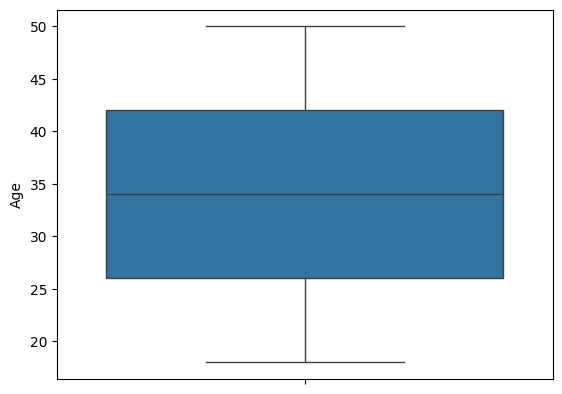

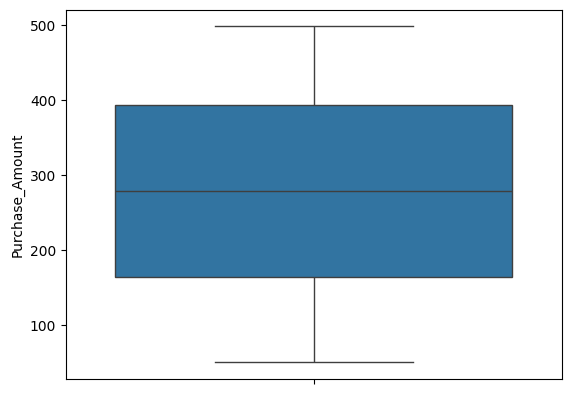

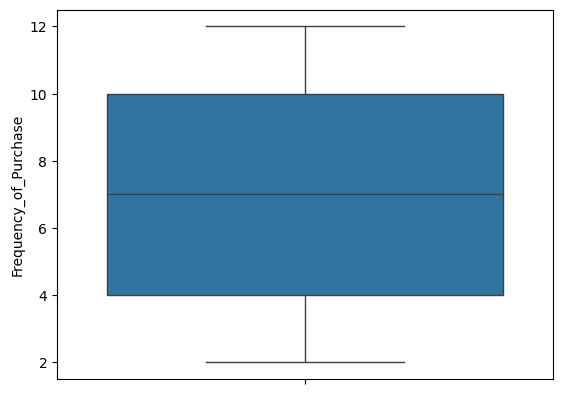

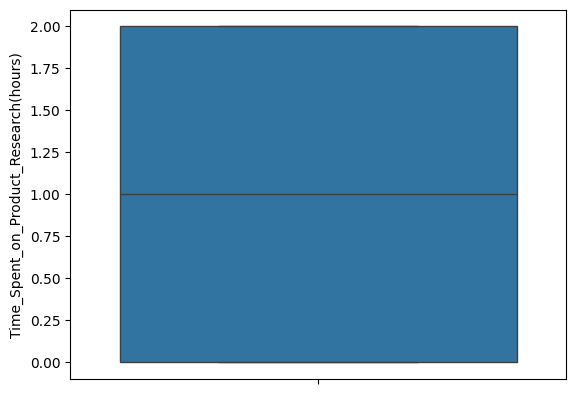

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

for column in columns_numeric : 
    sns.boxplot(data=df[column])
    plt.show()

## 3. Build Model

Membangun model logistic regression dengan data yang sudah dipersiapkan pada tahap sebelumnya

Pisahkan kolom fitur dan target (Outcome)

In [19]:
x = df.drop(columns=['Education_Level'])
y = df['Education_Level']

Standarisasi kolom fitur

In [20]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x = scaler.fit_transform(x)

Bagi data menjadi data training dan data testing

In [21]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


Latih modelnya menggunakan algoritma Logistic Regression


In [22]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)



## 4. Evaluate the model (before tuning)

Setelah membangun model dengan melatih dan memprediksi, selanjutnya mengevaluasi model

Evaluasi model yang telah dilatih dengan algoritma LogisticRegression sebelumnya

In [23]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

accuracy = accuracy_score(y_test, y_pred)
print(accuracy)
conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)
class_report = classification_report(y_test, y_pred)
print(class_report)

0.33774834437086093
[[21 13 11]
 [23 20 12]
 [25 16 10]]
              precision    recall  f1-score   support

           0       0.30      0.47      0.37        45
           1       0.41      0.36      0.38        55
           2       0.30      0.20      0.24        51

    accuracy                           0.34       151
   macro avg       0.34      0.34      0.33       151
weighted avg       0.34      0.34      0.33       151



In [24]:
import statsmodels.api as sm

x_train_const = sm.add_constant(x_train)

mnlogit_model = sm.MNLogit(y_train, x_train_const)
mnlogit_result = mnlogit_model.fit()

print(mnlogit_result.summary())

Optimization terminated successfully.
         Current function value: 1.079275
         Iterations 4
                          MNLogit Regression Results                          
Dep. Variable:        Education_Level   No. Observations:                  602
Model:                        MNLogit   Df Residuals:                      574
Method:                           MLE   Df Model:                           26
Date:                Wed, 13 May 2026   Pseudo R-squ.:                 0.01609
Time:                        20:37:42   Log-Likelihood:                -649.72
converged:                       True   LL-Null:                       -660.35
Covariance Type:            nonrobust   LLR p-value:                    0.7290
Education_Level=1       coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -0.0981      0.101     -0.974      0.330      -0.295       0.099
x1      

# Deployment

Save Model


In [25]:
from joblib import dump
dump(model, 'Logistic.pkl')

['Logistic.pkl']

Konfigurasi Token

In [26]:
!ngrok config add-authtoken 

ERROR:  accepts 1 arg(s), received 0


Konfigurasi Streamlit

In [27]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
import seaborn as sns
import io

st.set_page_config(
    page_title="Dashboard Prediksi Tingkat Pendidikan Berdasarkan Customer Behavior",
    page_icon="💰",
)
st.title("Education Prediction based on Customer Behavior")
st.write("Aplikasi ini memprediksi tingkat pendidikan berdasarkan perilaku konsumen.") # Ubah deskripsi

st.markdown("---")
st.subheader("Evaluasi Model")

# 1. Load Model yang sudah dilatih sebelumnya dan Scaler
model = joblib.load("Logistic.pkl")

# 2. Load dan persiapkan data sama seperti saat melatih model sebelumnya
data_eval = pd.read_csv("Ecommerce_Consumer_Behavior_Analysis_Data.csv") # Ganti nama variabel agar tidak bentrok
columns_to_keep = [
    "Age", "Gender", "Income_Level", "Education_Level",
    "Occupation", "Purchase_Category", "Purchase_Amount", "Frequency_of_Purchase",
    "Time_Spent_on_Product_Research(hours)",
    "Social_Media_Influence", "Device_Used_for_Shopping", "Payment_Method",
    "Discount_Used", "Customer_Loyalty_Program_Member"
]
columns_category_eval = [ # Definisikan kolom kategori untuk evaluasi
   "Gender",  "Income_Level", "Occupation", # Education_Level adalah target, jadi tidak di-encode sebagai fitur
   "Purchase_Category", "Social_Media_Influence",
   "Device_Used_for_Shopping", "Payment_Method",
   "Discount_Used", "Customer_Loyalty_Program_Member"
]

# 2.1 Drop Column yang tidak diperlukan
data_eval = data_eval.drop(columns='Customer_ID', errors='ignore') # errors='ignore' jika sudah di-drop
data_eval = data_eval[columns_to_keep]

# 2.2 Handle Missing Values (konsisten dengan training)
data_eval = data_eval.dropna(subset=["Social_Media_Influence"]) # Sama seperti di notebook

# 2.3 Mengubah Tipe Data Kolom Kategori (Label Encoding)
label_encoders_eval = {}
for column in columns_category_eval:
    if column in data_eval.columns:
        le_eval = LabelEncoder()
        data_eval[column] = le_eval.fit_transform(data_eval[column].astype(str))
        label_encoders_eval[column] = le_eval

# Mengubah Tipe Data Kolom Purchase Amount
if "Purchase_Amount" in data_eval.columns:
    data_eval["Purchase_Amount"] = data_eval["Purchase_Amount"].replace("[\$,]", "", regex=True).astype(float)

# 2.4 Pisahkan data menjadi fitur dan target
# Memastikan kolom 'Education_Level' ada dan sudah di-encode (sebagai target)
if 'Education_Level' in data_eval.columns:
    le_target_eval = LabelEncoder()
    # Cek apakah Education_Level ada sebelum mencoba drop
    if 'Education_Level' not in data_eval.columns:
        st.error("Kolom target 'Education_Level' tidak ditemukan dalam data evaluasi.")
        st.stop()
    le_education_target_eval = LabelEncoder()
    data_eval['Education_Level_Target_Encoded'] = le_education_target_eval.fit_transform(data_eval['Education_Level'].astype(str))


    X_eval = data_eval.drop(columns=['Education_Level', 'Education_Level_Target_Encoded']) # Drop kolom string asli dan target yang sudah diencode
    y_eval = data_eval['Education_Level_Target_Encoded'] # Gunakan target yang sudah diencode
else:
    st.error("Kolom 'Education_Level' tidak ditemukan untuk evaluasi.")
    st.stop()


# 2.5 Standarisasi Fitur (PENTING!)
scaler_eval_app = StandardScaler()
X_eval_scaled = scaler_eval_app.fit_transform(X_eval) 

# 2.6 Buat prediksi menggunakan model yang sudah dilatih
y_pred_eval = model.predict(X_eval_scaled)
y_prob_eval = model.predict_proba(X_eval_scaled)

# 2.7 Hitung metrik evaluasi
acc = accuracy_score(y_eval, y_pred_eval)
prec = precision_score(y_eval, y_pred_eval, average='weighted', zero_division=0)
rec = recall_score(y_eval, y_pred_eval, average='weighted', zero_division=0)
f1 = f1_score(y_eval, y_pred_eval, average='weighted', zero_division=0)
# roc_auc = roc_auc_score(y_eval, y_prob_eval, multi_class='ovr', average='weighted') # Untuk multiclass

col1, col2, col3, col4 = st.columns(4)
with col1:
    st.metric(label="Accuracy", value=f"{acc:.2f}")
with col2:
    st.metric(label="Precision", value=f"{prec:.2f}")
with col3:
    st.metric(label="Recall", value=f"{rec:.2f}")
with col4:
    st.metric(label="F1-Score", value=f"{f1:.2f}")
    # st.metric(label="ROC AUC", value=f"{roc_auc:.2f}")


plot_option = st.selectbox("Pilih grafik untuk ditampilkan:", ["Pilih", "Confusion Matrix"])

if plot_option == "Confusion Matrix":
    st.subheader("Confusion Matrix")
    cm = confusion_matrix(y_eval, y_pred_eval)
    fig, ax = plt.subplots()
    class_labels = le_education_target_eval.classes_ if 'le_education_target_eval' in locals() else np.unique(y_eval)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, xticklabels=class_labels, yticklabels=class_labels)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    st.pyplot(fig)

st.markdown("---")
st.subheader("Prediksi Education Level untuk Input Baru")

# Mendapatkan daftar unik dari data_eval untuk selectbox
# Ini sebaiknya diambil dari data asli sebelum di-encode di notebook untuk mendapatkan string yang benar
# Atau simpan mapping dari LabelEncoder di notebook

# Ambil contoh unik dari data_eval SEBELUM di-encode untuk opsi selectbox
# Ini adalah pendekatan sementara. Idealnya, opsi ini statis atau dari mapping yang disimpan.
original_data_for_options = pd.read_csv("Ecommerce_Consumer_Behavior_Analysis_Data.csv")
original_data_for_options = original_data_for_options.dropna(subset=["Social_Media_Influence"])


occupation_options = original_data_for_options['Occupation'].unique().tolist() if 'Occupation' in original_data_for_options else ["Engineer", "Doctor", "Teacher"]
purchase_category_options = original_data_for_options['Purchase_Category'].unique().tolist() if 'Purchase_Category' in original_data_for_options else ["Electronics", "Clothing"]
social_media_options = original_data_for_options['Social_Media_Influence'].unique().tolist() if 'Social_Media_Influence' in original_data_for_options else ["High", "Medium", "Low"]
device_options = original_data_for_options['Device_Used_for_Shopping'].unique().tolist() if 'Device_Used_for_Shopping' in original_data_for_options else ["Mobile", "Desktop", "Tablet"]
payment_options = original_data_for_options['Payment_Method'].unique().tolist() if 'Payment_Method' in original_data_for_options else ["Credit Card", "E-Wallet"]
income_options = original_data_for_options['Income_Level'].unique().tolist() if 'Income_Level' in original_data_for_options else ["Low", "Medium", "High"]


with st.form("prediction_form"):
    Age = st.number_input("Usia", min_value=10, max_value=100, value=30)
    Gender = st.selectbox("Jenis Kelamin", ["Male", "Female"]) 
    Income_Level = st.selectbox("Tingkat Pendapatan", income_options)
    Occupation = st.selectbox("Pekerjaan", occupation_options)
    Purchase_Category = st.selectbox("Kategori Pembelian", purchase_category_options)
    Purchase_Amount_str = st.text_input("Jumlah Pembelian (contoh: $100.50 atau 100.50)", value="$50") 
    Frequency_of_Purchase = st.number_input("Frekuensi Pembelian", min_value=0.0, value=5.0)
    Time_Spent_on_Product_Research = st.number_input("Waktu Riset Produk (jam)", min_value=0.0, value=2.0)
    Social_Media_Influence = st.selectbox("Pengaruh Media Sosial", social_media_options)
    Device_Used_for_Shopping = st.selectbox("Perangkat yang Digunakan", device_options)
    Payment_Method = st.selectbox("Metode Pembayaran", payment_options)
    Discount_Used = st.selectbox("Menggunakan Diskon?", ["Yes", "No"])
    Customer_Loyalty_Program_Member = st.selectbox("Anggota Loyalitas?", ["Yes", "No"]) 

    submit = st.form_submit_button("Prediksi Tingkat Pendidikan")

if submit:
    try:
        # Membuat DataFrame dari input
        input_data = {
            "Age": Age,
            "Gender": Gender,
            "Income_Level": Income_Level,
            "Occupation": Occupation,
            "Purchase_Category": Purchase_Category,
            "Purchase_Amount": Purchase_Amount_str,
            "Frequency_of_Purchase": Frequency_of_Purchase,
            "Time_Spent_on_Product_Research(hours)": Time_Spent_on_Product_Research,
            "Social_Media_Influence": Social_Media_Influence,
            "Device_Used_for_Shopping": Device_Used_for_Shopping,
            "Payment_Method": Payment_Method,
            "Discount_Used": Discount_Used,
            "Customer_Loyalty_Program_Member": Customer_Loyalty_Program_Member
        }
        input_df = pd.DataFrame([input_data])

        # Preprocessing input_df (HARUS SAMA DENGAN TRAINING DAN EVALUASI DI ATAS)
        # 1. Label Encoding untuk kolom kategori
        for column in columns_category_eval: # Gunakan list kolom kategori yang sama
            if column in input_df.columns:
                # Gunakan encoder yang sudah di-fit dari data evaluasi/training
                # atau fit encoder baru jika tidak disimpan (kurang ideal)
                current_le = label_encoders_eval.get(column)
                if current_le:
                    # Tangani jika input kategori tidak ada di encoder yang sudah di-fit
                    # Ini penting jika kategori input baru. Cara termudah: error atau default.
                    # Atau, latih ulang encoder dengan semua kemungkinan nilai.
                    # Untuk selectbox, ini seharusnya tidak terjadi jika opsinya dari data asli.
                    try:
                        input_df[column] = current_le.transform(input_df[column].astype(str))
                    except ValueError:
                        # Jika nilai baru, assign nilai default (misalnya -1 atau kategori paling umum)
                        # atau beritahu pengguna. Paling aman, pastikan selectbox hanya berisi nilai yang dikenal.
                        st.warning(f"Kategori '{input_df[column].iloc[0]}' untuk '{column}' tidak dikenal. Menggunakan nilai default atau prediksi mungkin tidak akurat.")
                        # Bisa juga dengan menambahkan kategori baru ke encoder, tapi ini mengubah state encoder
                        # current_le.classes_ = np.append(current_le.classes_, input_df[column].iloc[0])
                        # input_df[column] = current_le.transform(input_df[column].astype(str))
                        # Untuk sementara, kita coba skip transform jika error, yang akan jadi NaN atau error di scaler
                        input_df[column] = -1 # Nilai placeholder, perlu penanganan lebih baik
                else:
                    # Jika encoder tidak ada (seharusnya tidak terjadi jika columns_category_eval benar)
                    temp_le = LabelEncoder()
                    input_df[column] = temp_le.fit_transform(input_df[column].astype(str))


        # 2. Konversi Purchase_Amount
        if "Purchase_Amount" in input_df.columns:
            input_df["Purchase_Amount"] = input_df["Purchase_Amount"].replace("[\$,]", "", regex=True).astype(float)

        # 3. Standarisasi Fitur
        # Gunakan scaler yang sama yang di-fit pada data training (atau data eval di atas sebagai proxy)
        input_df_scaled = scaler_eval_app.transform(input_df) # Seharusnya scaler dari training

        # Prediksi
        prediction_encoded = model.predict(input_df_scaled)[0]
        # proba = model.predict_proba(input_df_scaled)[0] # Untuk probabilitas per kelas

        # Ubah prediksi numerik kembali ke label string asli
        # Muat encoder target yang disimpan, atau gunakan yang di-fit di bagian evaluasi
        # le_target_loaded = joblib.load('education_target_encoder.pkl')
        # prediction_label = le_target_loaded.inverse_transform([prediction_encoded])[0]
        prediction_label = le_education_target_eval.inverse_transform([prediction_encoded])[0]


        st.subheader("Hasil Prediksi")
        st.success(f"Tingkat Pendidikan yang Diprediksi: *{prediction_label}*")
        # st.write(f"Probabilitas per kelas: {proba}") # Tampilkan jika perlu

    except Exception as e:
        st.error(f"Terjadi error saat prediksi: {e}")
        st.info("Pastikan semua input sudah benar dan sesuai format.")

Overwriting app.py


In [28]:
from pyngrok import ngrok
import threading
import time
import os

In [29]:
def run_streamlit():
    os.system("streamlit run app.py --server.port 8501")

thread = threading.Thread(target=run_streamlit, daemon=True)
thread.start()

time.sleep(5)

public_url = ngrok.connect(addr=8501)
print(f"Streamlit app is live at: {public_url}")

Streamlit app is live at: NgrokTunnel: "https://be6e-2404-8000-1005-217c-79ec-968a-4724-67ca.ngrok-free.app" -> "http://localhost:8501"
